# Flood Hazard Model — Random Forest

This notebook trains a Random Forest to predict flood hazard scores for buildings in Nairobi.

**Input:** latitude + longitude of a building  
**Output:** 6 hazard scores (common → extreme + severity)

**Why only lat/lon?**  
Flood risk depends on *where* a building sits — elevation, proximity to rivers, drainage.  


## Step 1 — Load the data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/exposure_nairobi_with_hazard.csv")
print(f"{len(df)} buildings loaded")
df.head()

600 buildings loaded


,loc_id,lat,lon,housing_class,floor_area_m2,cost_per_m2_kes,tiv_kes,synthetic,source,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme,hazard_severity
0,NBO-0000,-1.314897,36.935883,semi_permanent,38,13600,5170000.0,True,"generated for hackathon starter kit, not a rea...",0.023286,0.000000,0.000000,0.000000,0.000000,0.2
1,NBO-0001,-1.219963,36.789855,informal_iron_sheet,8,7800,625000.0,True,"generated for hackathon starter kit, not a rea...",0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,NBO-0002,-1.257597,36.896201,semi_permanent,33,10000,3300000.0,True,"generated for hackathon starter kit, not a rea...",0.458406,0.407297,0.345205,0.247281,0.134603,1.0
3,NBO-0003,-1.194103,36.847820,semi_permanent,58,13700,7945000.0,True,"generated for hackathon starter kit, not a rea...",0.113963,0.030351,0.000000,0.000000,0.000000,0.4
4,NBO-0004,-1.263191,36.773582,semi_permanent,78,15900,12400000.0,True,"generated for hackathon starter kit, not a rea...",0.140621,0.059524,0.000000,0.000000,0.000000,0.4


## Step 2 — Explore the targets

The dataset has 6 hazard columns we want to predict.  
Notice that ~57% of `hazard_score_common` values are **zero** — most buildings are outside flood zones.

In [2]:
TARGETS = [
    "hazard_score_common",
    "hazard_score_occasional",
    "hazard_score_moderate",
    "hazard_score_severe",
    "hazard_score_extreme",
    "hazard_severity",
]

# How many zeros per target?
zero_counts = (df[TARGETS] == 0).sum()
print("Zero counts per target:")
print(zero_counts)

Zero counts per target:
hazard_score_common        341
hazard_score_occasional    426
hazard_score_moderate      490
hazard_score_severe        549
hazard_score_extreme       568
hazard_severity            341
dtype: int64


## Step 3 — Define features and targets

In [3]:
FEATURES = ["lat", "lon"]   # geographic only

X = df[FEATURES]
y = df[TARGETS]

print("X shape:", X.shape)   # (600, 2)
print("y shape:", y.shape)   # (600, 6)
X.head()

X shape: (600, 2)
y shape: (600, 6)


,lat,lon
0,-1.314897,36.935883
1,-1.219963,36.789855
2,-1.257597,36.896201
3,-1.194103,36.847820
4,-1.263191,36.773582


## Step 4 — Train / test split

Hold out 20% of rows so we can measure how well the model generalises to unseen buildings.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")

Train: 480 rows  |  Test: 120 rows


## Step 5 — Train the Random Forest

sklearn's `RandomForestRegressor` handles multiple output columns automatically.

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Model trained.")

Model trained.


## Step 6 — Apply zero cutoff

Random forests average many trees, so they almost never predict exactly 0.  
Without a fix, the model assigns small positive scores to buildings that should be zero — inflating losses.

**Fix:** snap any prediction below 0.03 to exactly 0.0.

In [6]:
ZERO_CUTOFF = 0.03

def apply_cutoff(preds):
    out = preds.copy()
    out[out < ZERO_CUTOFF] = 0.0
    return out

# Predict on the full dataset
all_preds = apply_cutoff(rf.predict(X))

# Compare zero counts before vs after cutoff
raw_preds = rf.predict(X)
print("Zeros before cutoff:", (raw_preds[:, 0] == 0).sum())
print("Zeros after  cutoff:", (all_preds[:, 0] == 0).sum())
print("Actual zeros        :", (df["hazard_score_common"] == 0).sum())

Zeros before cutoff: 48
Zeros after  cutoff: 315
Actual zeros        : 341


## Step 7 — Tier ordering check

Physically, a *common* flood must be at least as likely as an *occasional* one, and so on.  
We assert: `common ≥ occasional ≥ moderate ≥ severe ≥ extreme` for every building.

In [7]:
scores = all_preds[:, :5]   # columns 0-4 are the five hazard scores

violations = np.sum(
    ~(
        (scores[:, 0] >= scores[:, 1]) &
        (scores[:, 1] >= scores[:, 2]) &
        (scores[:, 2] >= scores[:, 3]) &
        (scores[:, 3] >= scores[:, 4])
    )
)

print(f"Tier ordering violations: {violations} / {len(all_preds)}")
assert violations == 0, "Tier ordering broken — do not save this model!"

Tier ordering violations: 0 / 600


## Step 8 — Evaluate on the test set

**MAE** = average absolute error (lower is better, scores range 0–1)  
**R²** = fraction of variance explained (1.0 = perfect, 0.0 = no better than the mean)

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

test_preds = apply_cutoff(rf.predict(X_test))

print(f"{'Target':<30} {'MAE':>8} {'R²':>8}")
print("-" * 48)
for i, t in enumerate(TARGETS):
    mae = mean_absolute_error(y_test.iloc[:, i], test_preds[:, i])
    r2  = r2_score(y_test.iloc[:, i], test_preds[:, i])
    print(f"{t:<30} {mae:>8.4f} {r2:>8.4f}")

Target                              MAE       R²
------------------------------------------------
hazard_score_common              0.0568   0.5968
hazard_score_occasional          0.0495   0.5032
hazard_score_moderate            0.0383   0.4163
hazard_score_severe              0.0292   0.2974
hazard_score_extreme             0.0206   0.2133
hazard_severity                  0.1306   0.6461


## Step 9 — Financial independence check

Two buildings at the **same location** but different financial values must get **identical** hazard scores.  
This confirms financial data has zero influence on the model.

In [9]:
loc = pd.DataFrame([{"lat": -1.257597, "lon": 36.896201}])

# Predict twice — same location, model only sees lat/lon so result must be identical
pred1 = apply_cutoff(rf.predict(loc))[0]
pred2 = apply_cutoff(rf.predict(loc))[0]

print("Scores for this location:", pred1)
print("Financially independent :", np.allclose(pred1, pred2))

Scores for this location: [0.1704333  0.1190273  0.08699944 0.04393559 0.         0.425     ]
Financially independent : True


## Step 10 — Feature importance

Only `lat` and `lon` should appear — no financial features.

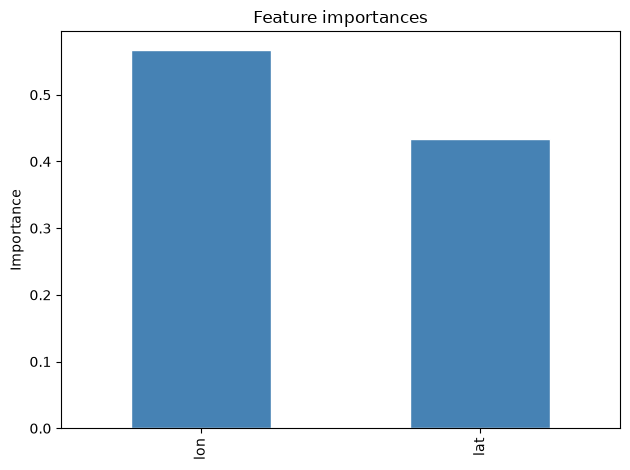

lon    0.566804
lat    0.433196
dtype: float64


In [10]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

importances.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Feature importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print(importances)

## Step 11 — Actual vs Predicted plot

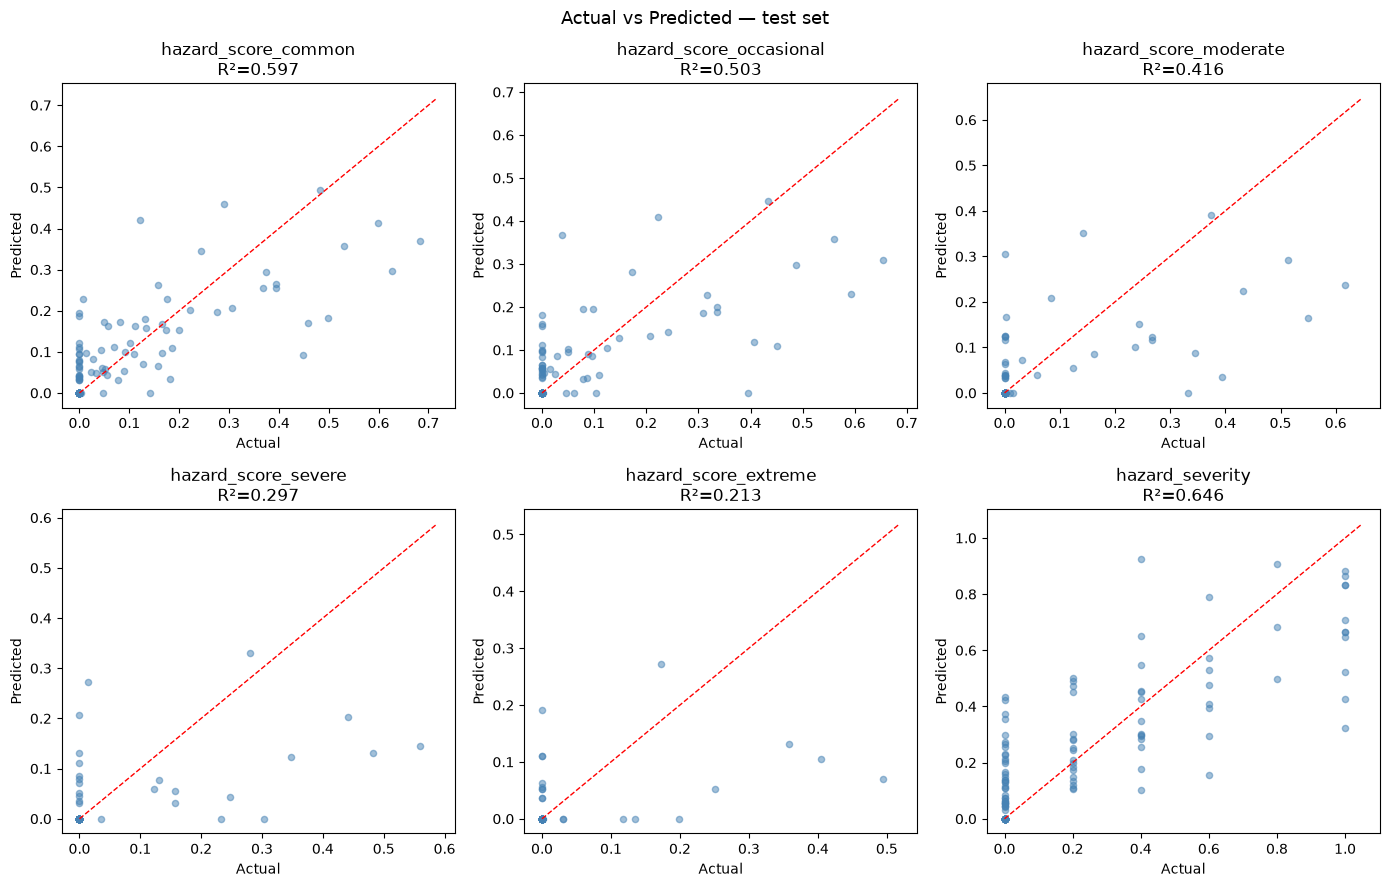

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Actual vs Predicted — test set", fontsize=13)

for idx, (ax, t) in enumerate(zip(axes.flat, TARGETS)):
    actual    = y_test.iloc[:, idx].values
    predicted = test_preds[:, idx]
    r2        = r2_score(actual, predicted)

    ax.scatter(actual, predicted, alpha=0.5, s=20, color="steelblue")
    lim = max(actual.max(), predicted.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_title(f"{t}\nR²={r2:.3f}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

## Step 12 — Save the model

We wrap the trained RF + the zero cutoff into a single `HazardPipeline` object.  
This way every caller (the API, batch jobs) automatically gets clean outputs — no one needs to remember to apply the cutoff manually.

In [12]:
import sys, joblib
from pathlib import Path

# Make the random_forest_model package importable from this notebook
sys.path.insert(0, str(Path("../").resolve()))
from random_forest_model.pipeline import HazardPipeline

pipeline = HazardPipeline(rf, ZERO_CUTOFF)

model_path = Path("../random_forest_model/hazard_random_forest.joblib")
joblib.dump(pipeline, model_path)

print(f"Model saved to {model_path.resolve()}")

Model saved to /home/vin/Desktop/fusion-backend/random_forest_model/hazard_random_forest.joblib
